In [1]:
%matplotlib inline

import json
import os

import matplotlib.pyplot as plt
import pandas as pd

from kibad_llm.config import PROJ_ROOT

# swith to project root to use same paths as in commands
os.chdir(PROJ_ROOT)
# set wider column width for displaying pandas data frames
pd.set_option("max_colwidth", 400)

2025-12-11 10:21:29.254 | INFO     | kibad_llm.config:<module>:11 - PROJ_ROOT path is: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm


In [2]:
metrics_file = "data/prediction_results/2025-11-25_19-49-41/job_return_value.json"
with open(metrics_file, "rb") as fin:
    metrics = json.load(fin)
f"loaded {len(metrics)} metrics"

'loaded 31 metrics'

In [3]:
metrics_df = pd.DataFrame.from_dict(metrics).T
metrics_df.head()

,precision,recall,f1,support
biodiversity_level,0.295775,0.313433,0.304348,67.0
biodiversity_variable,0.007092,0.014706,0.009569,68.0
climate,0.163934,0.500000,0.246914,20.0
conservation_area,0.000000,0.000000,0.000000,2.0
direct_driver,0.355556,0.340426,0.347826,94.0


<Axes: >

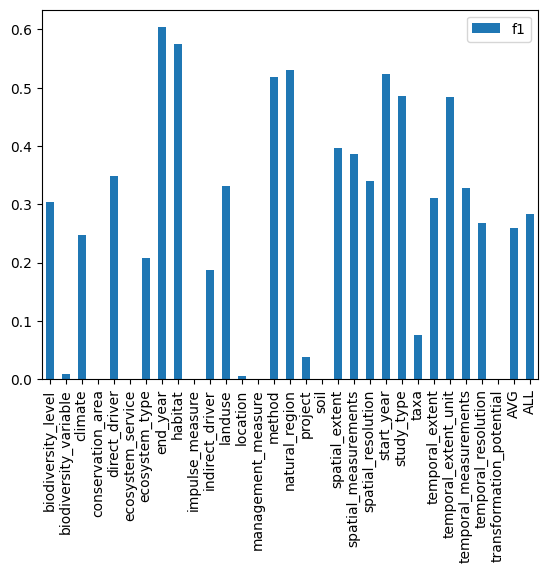

In [4]:
# fig, ax = plt.subplots()
#
# labels = metrics_df.index.to_list()
# f1 = metrics_df['f1']
metrics_df.plot.bar(y="f1")  # y=['precision','recall','f1'])

In [5]:
# load metrics for several runs. Expects the metrics file to be named 'job_return_value.json'
# specified as a dict to manually add a descriptive label per run
run_folders = {"2025-12-10_13-36-31": "gpt-oss-20b",
               "2025-12-10_14-48-27": "qwen3-30b",
               "2025-12-11_09-19-30": "nemotron-nano-12b",
               "2025-12-11_09-23-34": "mistral small 3.2 24b",
               "2025-12-11_10-18-31": "gemma3-27b"}
metrics_dict = {}
for folder in run_folders.keys():
    metrics_file = f"data/prediction_results/{folder}/job_return_value.json"
    with open(metrics_file, "rb") as fin:
        metrics_dict[folder] = json.load(fin)
f"loaded metrics for {len(metrics_dict)} run(s)"

'loaded metrics for 5 run(s)'

In [6]:
run_metrics_df = pd.DataFrame.from_dict({k: v["ALL"] for k, v in sorted(metrics_dict.items())}).T
run_metrics_df["run"] = [run_folders[k] for k, _ in sorted(metrics_dict.items())]
run_metrics_df.head()

,precision,recall,f1,support,run
2025-12-10_13-36-31,0.246658,0.341667,0.286491,1080.0,gpt-oss-20b
2025-12-10_14-48-27,0.344000,0.278704,0.307928,1080.0,qwen3-30b
2025-12-11_09-19-30,0.265564,0.252778,0.259013,1080.0,nemotron-nano-12b
2025-12-11_09-23-34,0.161290,0.333333,0.217391,1080.0,mistral small 3.2 24b
2025-12-11_10-18-31,0.182463,0.262037,0.215127,1080.0,gemma3-27b


<Axes: xlabel='run'>

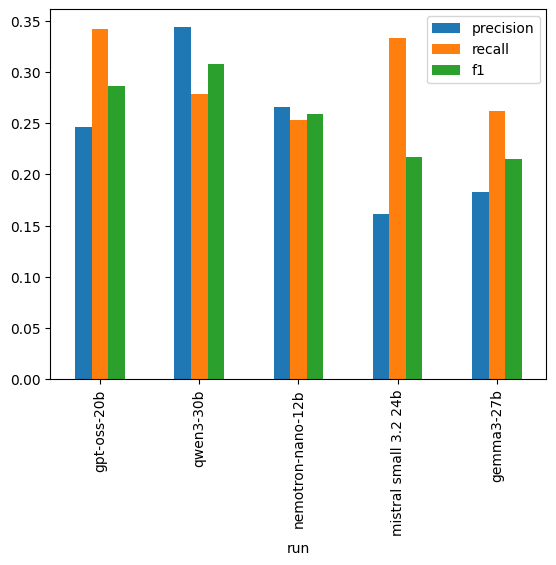

In [7]:
run_metrics_df.plot.bar(x="run", y=["precision", "recall", "f1"])  # y=['precision','recall','f1'])